Cell 1 — Mount Google Drive

In [1]:
# ✅ Kaggle Environment Setup
# No Google Drive mount needed on Kaggle.
# Output files are saved to /kaggle/working/
# CelebA dataset is available at /kaggle/input/celeba-dataset/
import os
print('Kaggle working dir:', os.listdir('/kaggle/working') if os.path.exists('/kaggle/working') else 'empty')
print('Input datasets:', os.listdir('/kaggle/input') if os.path.exists('/kaggle/input') else 'none')


Kaggle working dir: ['.virtual_documents']
Input datasets: ['datasets']


Cell 2 — Install packages

In [2]:
# Install packages not pre-installed on Kaggle (Internet must be ON)
!pip -q install thop torch-fidelity
# torchmetrics, torchvision, tqdm, einops, pandas, matplotlib, pillow are pre-installed
print('All packages ready.')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.6/85.6 kB 3.1 MB/s eta 0:00:00
All packages ready.


Cell 3 — Imports and seed

In [3]:
import os
import math
import json
import time
import copy
import random
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, utils
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

def seed_all(seed=42):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_all(42)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cuda


Cell 4 — Drive paths

In [4]:
from pathlib import Path

# ✅ Kaggle paths — all outputs go to /kaggle/working/
PROJECT_ROOT = Path("/kaggle/working/CSE499B_Lightweight_Diffusion")

CKPT_DIR   = PROJECT_ROOT / "checkpoints_phase3_celeba_compare"
RESULT_DIR = PROJECT_ROOT / "results_phase3_celeba_compare"
SAMPLE_DIR = PROJECT_ROOT / "samples_phase3_celeba_compare"
CONFIG_DIR = PROJECT_ROOT / "configs_phase3_celeba_compare"

for p in [CKPT_DIR, RESULT_DIR, SAMPLE_DIR, CONFIG_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("CKPT_DIR    :", CKPT_DIR)
print("RESULT_DIR  :", RESULT_DIR)
print("SAMPLE_DIR  :", SAMPLE_DIR)
print("CONFIG_DIR  :", CONFIG_DIR)


PROJECT_ROOT: /kaggle/working/CSE499B_Lightweight_Diffusion
CKPT_DIR    : /kaggle/working/CSE499B_Lightweight_Diffusion/checkpoints_phase3_celeba_compare
RESULT_DIR  : /kaggle/working/CSE499B_Lightweight_Diffusion/results_phase3_celeba_compare
SAMPLE_DIR  : /kaggle/working/CSE499B_Lightweight_Diffusion/samples_phase3_celeba_compare
CONFIG_DIR  : /kaggle/working/CSE499B_Lightweight_Diffusion/configs_phase3_celeba_compare


Cell 5 — Base config

In [5]:
BASE = {
    "dataset": "CELEBA",
    "image_size": 64,
    "channels": 3,
    "batch_size": 64,
    "num_workers": 2,

    "T": 1000,
    "beta_start": 1e-4,
    "beta_end": 0.02,

    "epochs": 30,
    "lr": 2e-4,
    "weight_decay": 0.0,
    "grad_clip": 1.0,

    "ema": {
        "use": True,
        "decay": 0.999
    },

    "sample": {
        "n_samples": 16,
        "grid_rows": 4,
        "ddim_steps": 50,
        "ddim_eta": 0.0
    },

    "eval": {
        "fid_real_limit": 2000,
        "fid_fake_limit": 2000,
        "speed_n_images": 64
    }
}

Cell 6 — Experiment configs

In [6]:
EXPS = {}

# Old baseline style for CelebA
EXPS["old_baseline_celeba"] = copy.deepcopy(BASE)
EXPS["old_baseline_celeba"].update({
    "model": {
        "base_ch": 64,
        "ch_mults": [1, 2, 4, 8],
        "num_res_blocks": 2,
        "attn_resolutions": [16, 8],
        "time_dim": 256,
        "use_depthwise_mode": "none"
    }
})

# Proposed Variant A: safer lightweight
EXPS["variantA_celeba"] = copy.deepcopy(BASE)
EXPS["variantA_celeba"].update({
    "model": {
        "base_ch": 48,
        "ch_mults": [1, 2, 3, 4],
        "num_res_blocks": 1,
        "attn_resolutions": [8],   # bottleneck only
        "time_dim": 128,
        "use_depthwise_mode": "mid"
    }
})

# Proposed Variant B: stronger lightweight
EXPS["variantB_celeba"] = copy.deepcopy(BASE)
EXPS["variantB_celeba"].update({
    "model": {
        "base_ch": 32,
        "ch_mults": [1, 2, 3, 4],
        "num_res_blocks": 1,
        "attn_resolutions": [8],   # bottleneck only
        "time_dim": 128,
        "use_depthwise_mode": "all_internal"
    }
})

for name, cfg in EXPS.items():
    cfg_path = CONFIG_DIR / f"{name}.json"
    with open(cfg_path, "w") as f:
        json.dump(cfg, f, indent=2)
    print("Saved config:", cfg_path)

Saved config: /kaggle/working/CSE499B_Lightweight_Diffusion/configs_phase3_celeba_compare/old_baseline_celeba.json
Saved config: /kaggle/working/CSE499B_Lightweight_Diffusion/configs_phase3_celeba_compare/variantA_celeba.json
Saved config: /kaggle/working/CSE499B_Lightweight_Diffusion/configs_phase3_celeba_compare/variantB_celeba.json


Cell 7 — Dataset loader for CelebA

In [7]:
import os, glob
from PIL import Image
from torch.utils.data import Dataset, DataLoader

class KaggleCelebADataset(Dataset):
    """
    Works with the jessicali9530/celeba-dataset Kaggle dataset.
    Supports train / valid / test splits via list_eval_partition.csv.
    """
    SPLIT_MAP = {'train': 0, 'valid': 1, 'test': 2}

    def __init__(self, root, split='train', transform=None):
        self.transform = transform
        split_id = self.SPLIT_MAP[split]

        # ── locate images ────────────────────────────────────────────────
        # jessicali9530 dataset: images live in img_align_celeba/img_align_celeba/
        img_dir_candidates = [
            os.path.join(root, 'img_align_celeba', 'img_align_celeba'),
            os.path.join(root, 'img_align_celeba'),
            root,
        ]
        self.img_dir = None
        for candidate in img_dir_candidates:
            if os.path.isdir(candidate) and len(glob.glob(os.path.join(candidate, '*.jpg'))) > 0:
                self.img_dir = candidate
                break
        if self.img_dir is None:
            raise FileNotFoundError(f'Cannot find CelebA images under {root}')

        # ── locate partition file ────────────────────────────────────────
        partition_candidates = [
            os.path.join(root, 'list_eval_partition.csv'),
            os.path.join(root, 'list_eval_partition.txt'),
        ]
        partition_file = None
        for p in partition_candidates:
            if os.path.exists(p):
                partition_file = p
                break
        if partition_file is None:
            raise FileNotFoundError(f'Cannot find list_eval_partition in {root}')

        # ── parse partition ──────────────────────────────────────────────
        self.filenames = []
        with open(partition_file, 'r') as f:
            for line in f:
                line = line.strip()
                if not line or line.startswith('image_id'):  # skip CSV header
                    continue
                parts = line.replace(',', ' ').split()
                fname, part = parts[0], int(parts[1])
                if part == split_id:
                    full_path = os.path.join(self.img_dir, fname)
                    if os.path.exists(full_path):
                        self.filenames.append(full_path)

        if len(self.filenames) == 0:
            raise RuntimeError(f'No images found for split={split}. Check dataset path.')
        print(f'CelebA [{split}]: {len(self.filenames)} images found.')

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        img = Image.open(self.filenames[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, 0  # return dummy label to match original interface


def get_dataloaders(cfg):
    ds = cfg['dataset']
    img_size = cfg['image_size']
    bs = cfg['batch_size']
    num_workers = cfg['num_workers']

    if ds == 'CELEBA':
        tfm = transforms.Compose([
            transforms.CenterCrop(178),
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Lambda(lambda x: x * 2 - 1)
        ])

        # ✅ Kaggle CelebA dataset root
        CELEBA_ROOT = '/kaggle/input/datasets/jessicali9530/celeba-dataset'

        trainset = KaggleCelebADataset(root=CELEBA_ROOT, split='train', transform=tfm)
        testset  = KaggleCelebADataset(root=CELEBA_ROOT, split='test',  transform=tfm)

        trainloader = DataLoader(
            trainset, batch_size=bs, shuffle=True,
            num_workers=num_workers, pin_memory=True, drop_last=True
        )
        testloader = DataLoader(
            testset, batch_size=bs, shuffle=False,
            num_workers=num_workers, pin_memory=True, drop_last=False
        )
        return trainloader, testloader

    raise ValueError(f'Unsupported dataset: {ds}')


Cell 8 — Diffusion utilities

In [8]:
def make_beta_schedule(T, beta_start, beta_end):
    return torch.linspace(beta_start, beta_end, T)

class Diffusion:
    def __init__(self, T=1000, beta_start=1e-4, beta_end=0.02, device="cuda"):
        self.T = T
        self.device = device

        self.betas = make_beta_schedule(T, beta_start, beta_end).to(device)
        self.alphas = 1.0 - self.betas
        self.alphas_cumprod = torch.cumprod(self.alphas, dim=0)
        self.alphas_cumprod_prev = torch.cat(
            [torch.tensor([1.0], device=device), self.alphas_cumprod[:-1]], dim=0
        )

        self.sqrt_alphas_cumprod = torch.sqrt(self.alphas_cumprod)
        self.sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - self.alphas_cumprod)
        self.sqrt_recip_alphas = torch.sqrt(1.0 / self.alphas)
        self.posterior_variance = (
            self.betas * (1.0 - self.alphas_cumprod_prev) / (1.0 - self.alphas_cumprod)
        )

    def sample_timesteps(self, n):
        return torch.randint(low=0, high=self.T, size=(n,), device=self.device)

    def noise_images(self, x, t):
        noise = torch.randn_like(x)
        sqrt_ac = self.sqrt_alphas_cumprod[t][:, None, None, None]
        sqrt_om = self.sqrt_one_minus_alphas_cumprod[t][:, None, None, None]
        return sqrt_ac * x + sqrt_om * noise, noise

Cell 9 — Model blocks

In [9]:
class DepthwiseSeparableConv(nn.Module):
    def __init__(self, in_ch, out_ch, k=3, p=1):
        super().__init__()
        self.dw = nn.Conv2d(in_ch, in_ch, kernel_size=k, padding=p, groups=in_ch, bias=False)
        self.pw = nn.Conv2d(in_ch, out_ch, kernel_size=1, bias=False)

    def forward(self, x):
        return self.pw(self.dw(x))

def conv3x3(in_ch, out_ch, mode="standard"):
    if mode == "depthwise":
        return DepthwiseSeparableConv(in_ch, out_ch, 3, 1)
    return nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1)

class SinusoidalPosEmb(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        half = self.dim // 2
        emb = math.log(10000) / max(half - 1, 1)
        emb = torch.exp(torch.arange(half, device=t.device) * -emb)
        emb = t[:, None].float() * emb[None, :]
        emb = torch.cat([emb.sin(), emb.cos()], dim=1)
        return emb

class TimeMLP(nn.Module):
    def __init__(self, time_dim):
        super().__init__()
        self.net = nn.Sequential(
            SinusoidalPosEmb(time_dim),
            nn.Linear(time_dim, time_dim * 2),
            nn.SiLU(),
            nn.Linear(time_dim * 2, time_dim)
        )

    def forward(self, t):
        return self.net(t)

class SelfAttention2d(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.norm = nn.GroupNorm(8, ch)
        self.q = nn.Conv2d(ch, ch, 1)
        self.k = nn.Conv2d(ch, ch, 1)
        self.v = nn.Conv2d(ch, ch, 1)
        self.proj = nn.Conv2d(ch, ch, 1)

    def forward(self, x):
        b, c, h, w = x.shape
        h_in = x
        x = self.norm(x)

        q = self.q(x).reshape(b, c, h * w).permute(0, 2, 1)
        k = self.k(x).reshape(b, c, h * w)
        v = self.v(x).reshape(b, c, h * w).permute(0, 2, 1)

        attn = torch.bmm(q, k) * (c ** -0.5)
        attn = torch.softmax(attn, dim=-1)

        out = torch.bmm(attn, v).permute(0, 2, 1).reshape(b, c, h, w)
        out = self.proj(out)
        return h_in + out

class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_dim, conv_mode="standard", use_attn=False):
        super().__init__()
        self.norm1 = nn.GroupNorm(8, in_ch)
        self.act1 = nn.SiLU()
        self.conv1 = conv3x3(in_ch, out_ch, mode=conv_mode)

        self.time_proj = nn.Sequential(
            nn.SiLU(),
            nn.Linear(time_dim, out_ch)
        )

        self.norm2 = nn.GroupNorm(8, out_ch)
        self.act2 = nn.SiLU()
        self.conv2 = conv3x3(out_ch, out_ch, mode=conv_mode)

        self.shortcut = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
        self.attn = SelfAttention2d(out_ch) if use_attn else nn.Identity()

    def forward(self, x, t_emb):
        h = self.conv1(self.act1(self.norm1(x)))
        h = h + self.time_proj(t_emb)[:, :, None, None]
        h = self.conv2(self.act2(self.norm2(h)))
        h = h + self.shortcut(x)
        h = self.attn(h)
        return h

class Downsample(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.conv = nn.Conv2d(ch, ch, kernel_size=4, stride=2, padding=1)

    def forward(self, x):
        return self.conv(x)

class Upsample(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.conv = nn.Conv2d(ch, ch, kernel_size=3, padding=1)

    def forward(self, x):
        x = F.interpolate(x, scale_factor=2, mode="nearest")
        return self.conv(x)

Cell 10 — U-Net model

In [10]:
class UNetDiffusion(nn.Module):
    def __init__(self, in_ch=3, out_ch=3, image_size=64, base_ch=64, ch_mults=[1,2,4,8],
                 num_res_blocks=2, time_dim=256, attn_resolutions=[16,8],
                 use_depthwise_mode="none"):
        super().__init__()

        self.image_size = image_size
        self.time_dim = time_dim
        self.time_mlp = TimeMLP(time_dim)

        self.in_conv = nn.Conv2d(in_ch, base_ch, kernel_size=3, padding=1)

        chs = [base_ch * m for m in ch_mults]
        self.down_blocks = nn.ModuleList()
        self.downsamples = nn.ModuleList()

        cur_ch = base_ch
        cur_res = image_size
        self.skip_channels = []

        for i, ch in enumerate(chs):
            stage = nn.ModuleList()
            for j in range(num_res_blocks):
                if use_depthwise_mode == "none":
                    conv_mode = "standard"
                elif use_depthwise_mode == "mid":
                    conv_mode = "depthwise" if (i > 0 and i < len(chs)-1) else "standard"
                else:
                    conv_mode = "depthwise"

                use_attn = cur_res in attn_resolutions
                block = ResBlock(cur_ch, ch, time_dim, conv_mode=conv_mode, use_attn=use_attn)
                stage.append(block)
                cur_ch = ch
                self.skip_channels.append(cur_ch)

            self.down_blocks.append(stage)

            if i != len(chs) - 1:
                self.downsamples.append(Downsample(cur_ch))
                cur_res //= 2

        self.mid_block1 = ResBlock(cur_ch, cur_ch, time_dim, conv_mode="standard", use_attn=True)
        self.mid_block2 = ResBlock(cur_ch, cur_ch, time_dim, conv_mode="standard", use_attn=False)

        self.up_blocks = nn.ModuleList()
        self.upsamples = nn.ModuleList()

        rev_chs = list(reversed(chs))
        rev_skip = list(reversed(self.skip_channels))
        cur_res = image_size // (2 ** (len(chs) - 1))

        for i, ch in enumerate(rev_chs):
            stage = nn.ModuleList()
            n_blocks_here = num_res_blocks
            for j in range(n_blocks_here):
                skip_ch = rev_skip.pop(0)

                if use_depthwise_mode == "none":
                    conv_mode = "standard"
                elif use_depthwise_mode == "mid":
                    conv_mode = "depthwise" if (i > 0 and i < len(rev_chs)-1) else "standard"
                else:
                    conv_mode = "depthwise"

                use_attn = cur_res in attn_resolutions
                block = ResBlock(cur_ch + skip_ch, ch, time_dim, conv_mode=conv_mode, use_attn=use_attn)
                stage.append(block)
                cur_ch = ch

            self.up_blocks.append(stage)

            if i != len(rev_chs) - 1:
                self.upsamples.append(Upsample(cur_ch))
                cur_res *= 2

        self.out_norm = nn.GroupNorm(8, cur_ch)
        self.out_act = nn.SiLU()
        self.out_conv = nn.Conv2d(cur_ch, out_ch, kernel_size=3, padding=1)

    def forward(self, x, t):
        t_emb = self.time_mlp(t)

        x = self.in_conv(x)
        skips = []

        for i, stage in enumerate(self.down_blocks):
            for block in stage:
                x = block(x, t_emb)
                skips.append(x)
            if i < len(self.downsamples):
                x = self.downsamples[i](x)

        x = self.mid_block1(x, t_emb)
        x = self.mid_block2(x, t_emb)

        for i, stage in enumerate(self.up_blocks):
            for block in stage:
                skip = skips.pop()
                x = torch.cat([x, skip], dim=1)
                x = block(x, t_emb)
            if i < len(self.upsamples):
                x = self.upsamples[i](x)

        x = self.out_conv(self.out_act(self.out_norm(x)))
        return x

def build_model_from_cfg(cfg):
    mcfg = cfg["model"]
    model = UNetDiffusion(
        in_ch=cfg["channels"],
        out_ch=cfg["channels"],
        image_size=cfg["image_size"],
        base_ch=mcfg["base_ch"],
        ch_mults=mcfg["ch_mults"],
        num_res_blocks=mcfg["num_res_blocks"],
        time_dim=mcfg["time_dim"],
        attn_resolutions=mcfg["attn_resolutions"],
        use_depthwise_mode=mcfg["use_depthwise_mode"]
    )
    return model.to(device)

Cell 11 — EMA, save/load helper

In [11]:
class EMA:
    def __init__(self, model, decay=0.999):
        self.decay = decay
        self.shadow = {k: v.detach().clone() for k, v in model.state_dict().items()}

    @torch.no_grad()
    def update(self, model):
        for k, v in model.state_dict().items():
            self.shadow[k].mul_(self.decay).add_(v.detach(), alpha=1 - self.decay)

    def copy_to(self, model):
        model.load_state_dict(self.shadow)

def milestone_full_path(exp_name, epoch):
    return CKPT_DIR / f"{exp_name}_epoch{epoch}.pt"

def latest_full_path(exp_name):
    return CKPT_DIR / f"{exp_name}_latest_full.pt"

def best_full_path(exp_name):
    return CKPT_DIR / f"{exp_name}_best_full.pt"

def ema_path(exp_name, epoch):
    return CKPT_DIR / f"{exp_name}_ema_epoch{epoch}.pt"

def trainlog_path(exp_name):
    return RESULT_DIR / f"{exp_name}_trainlog.json"

def evaljson_path(exp_name):
    return RESULT_DIR / f"{exp_name}_eval.json"

def save_json(obj, path):
    with open(path, "w") as f:
        json.dump(obj, f, indent=2)

def load_json(path, default=None):
    if Path(path).exists():
        with open(path, "r") as f:
            return json.load(f)
    return default

Cell 12 — DDPM and DDIM sampling

In [12]:
@torch.no_grad()
def ddpm_sample(model, diff, shape):
    model.eval()
    x = torch.randn(shape, device=diff.device)

    for i in tqdm(reversed(range(diff.T)), total=diff.T, desc="DDPM sampling"):
        t = torch.full((shape[0],), i, device=diff.device, dtype=torch.long)
        eps = model(x, t)

        alpha = diff.alphas[i]
        alpha_hat = diff.alphas_cumprod[i]
        beta = diff.betas[i]

        if i > 0:
            noise = torch.randn_like(x)
        else:
            noise = torch.zeros_like(x)

        x = (1 / torch.sqrt(alpha)) * (
            x - ((1 - alpha) / torch.sqrt(1 - alpha_hat)) * eps
        ) + torch.sqrt(beta) * noise

    return x

@torch.no_grad()
def ddim_sample(model, diff, shape, steps=50, eta=0.0):
    model.eval()
    x = torch.randn(shape, device=diff.device)

    times = torch.linspace(diff.T - 1, 0, steps, device=diff.device).long()

    for idx, i in enumerate(tqdm(times, desc="DDIM sampling")):
        t = torch.full((shape[0],), i.item(), device=diff.device, dtype=torch.long)
        eps = model(x, t)

        alpha_hat = diff.alphas_cumprod[i]
        sqrt_alpha_hat = torch.sqrt(alpha_hat)
        sqrt_one_minus_alpha_hat = torch.sqrt(1 - alpha_hat)

        x0_pred = (x - sqrt_one_minus_alpha_hat * eps) / sqrt_alpha_hat
        x0_pred = torch.clamp(x0_pred, -1, 1)

        if idx == len(times) - 1:
            x = x0_pred
        else:
            next_i = times[idx + 1]
            alpha_hat_next = diff.alphas_cumprod[next_i]

            sigma = eta * torch.sqrt(
                (1 - alpha_hat_next) / (1 - alpha_hat) * (1 - alpha_hat / alpha_hat_next)
            )
            noise = torch.randn_like(x) if eta > 0 else torch.zeros_like(x)

            x = (
                torch.sqrt(alpha_hat_next) * x0_pred +
                torch.sqrt(torch.clamp(1 - alpha_hat_next - sigma**2, min=0.0)) * eps +
                sigma * noise
            )

    return x

def to_01(x):
    return (x.clamp(-1, 1) + 1) / 2

Cell 13 — Metrics and sample saving

In [13]:
from thop import profile
from torchmetrics.image.fid import FrechetInceptionDistance

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def compute_params_macs(model, cfg):
    dummy_x = torch.randn(1, cfg["channels"], cfg["image_size"], cfg["image_size"]).to(device)
    dummy_t = torch.randint(0, cfg["T"], (1,), device=device)
    macs, params = profile(model, inputs=(dummy_x, dummy_t), verbose=False)
    return params, macs

@torch.no_grad()
def save_sample_grid(model, diff, cfg, out_path, n_samples=16, rows=4):
    x = ddim_sample(
        model,
        diff,
        shape=(n_samples, cfg["channels"], cfg["image_size"], cfg["image_size"]),
        steps=cfg["sample"]["ddim_steps"],
        eta=cfg["sample"]["ddim_eta"]
    )
    x = to_01(x)
    grid = utils.make_grid(x, nrow=rows)
    utils.save_image(grid, out_path)
    return out_path

@torch.no_grad()
def measure_sampling_speed(model, diff, cfg):
    n_imgs = cfg["eval"]["speed_n_images"]
    bs = 16
    total = 0
    start = time.time()

    while total < n_imgs:
        cur = min(bs, n_imgs - total)
        _ = ddim_sample(
            model, diff,
            shape=(cur, cfg["channels"], cfg["image_size"], cfg["image_size"]),
            steps=cfg["sample"]["ddim_steps"],
            eta=cfg["sample"]["ddim_eta"]
        )
        total += cur

    elapsed = time.time() - start
    return elapsed / n_imgs

@torch.no_grad()
def compute_fid(model, diff, cfg, testloader):
    fid = FrechetInceptionDistance(feature=2048, normalize=True).to(device)

    real_limit = cfg["eval"]["fid_real_limit"]
    fake_limit = cfg["eval"]["fid_fake_limit"]

    real_seen = 0
    for batch in tqdm(testloader, desc="FID real"):
        imgs = batch[0].to(device)
        imgs = to_01(imgs)
        fid.update(imgs, real=True)
        real_seen += imgs.size(0)
        if real_seen >= real_limit:
            break

    fake_seen = 0
    bs = testloader.batch_size
    while fake_seen < fake_limit:
        cur = min(bs, fake_limit - fake_seen)
        fake = ddim_sample(
            model, diff,
            shape=(cur, cfg["channels"], cfg["image_size"], cfg["image_size"]),
            steps=cfg["sample"]["ddim_steps"],
            eta=cfg["sample"]["ddim_eta"]
        )
        fake = to_01(fake)
        fid.update(fake, real=False)
        fake_seen += cur

    return float(fid.compute().item())

Cell 14 — Training function

In [14]:
def train_one_experiment(exp_name, cfg):
    print(f"\n========== TRAINING: {exp_name} ==========")

    trainloader, testloader = get_dataloaders(cfg)
    model = build_model_from_cfg(cfg)
    diff = Diffusion(
        T=cfg["T"],
        beta_start=cfg["beta_start"],
        beta_end=cfg["beta_end"],
        device=device
    )

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=cfg["lr"],
        weight_decay=cfg["weight_decay"]
    )

    scaler = torch.amp.GradScaler('cuda', enabled=(device == "cuda"))
    ema = EMA(model, decay=cfg["ema"]["decay"]) if cfg["ema"]["use"] else None

    log_data = []
    best_loss = 1e18

    for epoch in range(1, cfg["epochs"] + 1):
        model.train()
        running_loss = 0.0
        pbar = tqdm(trainloader, desc=f"{exp_name} | Epoch {epoch}/{cfg['epochs']}")

        for batch in pbar:
            imgs = batch[0].to(device)
            t = diff.sample_timesteps(imgs.size(0))
            x_t, noise = diff.noise_images(imgs, t)

            optimizer.zero_grad(set_to_none=True)

            with torch.amp.autocast('cuda', enabled=(device == "cuda")):
                pred = model(x_t, t)
                loss = F.mse_loss(pred, noise)

            scaler.scale(loss).backward()

            if cfg["grad_clip"] is not None:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), cfg["grad_clip"])

            scaler.step(optimizer)
            scaler.update()

            if ema is not None:
                ema.update(model)

            running_loss += loss.item()
            pbar.set_postfix(loss=f"{loss.item():.4f}")

        epoch_loss = running_loss / len(trainloader)
        log_data.append({"epoch": epoch, "loss": round(epoch_loss, 6)})
        save_json(log_data, trainlog_path(exp_name))

        state = {
            "epoch": epoch,
            "model": model.state_dict(),
            "optimizer": optimizer.state_dict(),
            "cfg": cfg,
            "loss": epoch_loss
        }

        torch.save(state, latest_full_path(exp_name))

        if epoch % 10 == 0 or epoch == cfg["epochs"]:
            torch.save(state, milestone_full_path(exp_name, epoch))

        if ema is not None and (epoch % 10 == 0 or epoch == cfg["epochs"]):
            torch.save({"epoch": epoch, "shadow": ema.shadow}, ema_path(exp_name, epoch))

        if epoch_loss < best_loss:
            best_loss = epoch_loss
            torch.save(state, best_full_path(exp_name))

        print(f"Epoch {epoch} done | avg loss = {epoch_loss:.6f}")

    return model, diff, trainloader, testloader

Cell 15 — Train all three models

In [15]:
trained_objects = {}

for exp_name, cfg in EXPS.items():
    model, diff, trainloader, testloader = train_one_experiment(exp_name, cfg)
    trained_objects[exp_name] = {
        "model": model,
        "diff": diff,
        "trainloader": trainloader,
        "testloader": testloader
    }

print("\nTraining finished for all experiments.")


========== TRAINING: old_baseline_celeba ==========
CelebA [train]: 162770 images found.
CelebA [test]: 19962 images found.


old_baseline_celeba | Epoch 1/30: 100%|██████████| 2543/2543 [21:07<00:00,  2.01it/s, loss=0.0187]


Epoch 1 done | avg loss = 0.030279


old_baseline_celeba | Epoch 2/30: 100%|██████████| 2543/2543 [21:18<00:00,  1.99it/s, loss=0.0157]


Epoch 2 done | avg loss = 0.019503


...

Epoch 27 done | avg loss = 0.016306


old_baseline_celeba | Epoch 28/30: 100%|██████████| 2543/2543 [21:33<00:00,  1.97it/s, loss=0.0110]


Epoch 28 done | avg loss = 0.016363


old_baseline_celeba | Epoch 29/30:  52%|█████▏    | 1322/2543 [11:08<10:17,  1.98it/s, loss=0.0198]


KeyboardInterrupt: 

Cell 16 — Load best/EMA model for evaluation

In [18]:
def load_eval_model(exp_name):
    cfg = copy.deepcopy(EXPS[exp_name])
    model = build_model_from_cfg(cfg)

    final_epoch = cfg["epochs"]
    ema_ckpt = ema_path(exp_name, final_epoch)
    best_ckpt = best_full_path(exp_name)
    latest_ckpt = latest_full_path(exp_name)

    chosen = None
    use_ema = False

    if ema_ckpt.exists():
        chosen = torch.load(ema_ckpt, map_location=device, weights_only=False)
        model.load_state_dict(chosen["shadow"])
        use_ema = True
        print(f"{exp_name}: using EMA checkpoint at epoch {final_epoch}")
    elif best_ckpt.exists():
        chosen = torch.load(best_ckpt, map_location=device, weights_only=False)
        model.load_state_dict(chosen["model"])
        print(f"{exp_name}: using BEST checkpoint")
    elif latest_ckpt.exists():
        chosen = torch.load(latest_ckpt, map_location=device, weights_only=False)
        model.load_state_dict(chosen["model"])
        print(f"{exp_name}: using LATEST checkpoint")
    else:
        raise FileNotFoundError(f"No checkpoint found for {exp_name}")

    diff = Diffusion(
        T=cfg["T"],
        beta_start=cfg["beta_start"],
        beta_end=cfg["beta_end"],
        device=device
    )

    return model.eval(), diff, cfg, use_ema

Cell 17 — Evaluate all models

In [19]:
# ✅ Only evaluating old_baseline_celeba (Variant A and B skipped — training not completed in this session)
results = []

EVAL_EXPS = ["old_baseline_celeba"]  # Only baseline this run

for exp_name in EVAL_EXPS:
    print(f"\n==============================")
    print(f"Evaluating: {exp_name}")
    print(f"==============================")

    model, diff, cfg, use_ema = load_eval_model(exp_name)
    _, testloader = get_dataloaders(cfg)

    params = count_params(model)
    thop_params, macs = compute_params_macs(model, cfg)
    speed = measure_sampling_speed(model, diff, cfg)
    fid = compute_fid(model, diff, cfg, testloader)

    sample_path = SAMPLE_DIR / f"{exp_name}_grid.png"
    save_sample_grid(
        model, diff, cfg,
        out_path=sample_path,
        n_samples=cfg["sample"]["n_samples"],
        rows=cfg["sample"]["grid_rows"]
    )

    train_log = load_json(trainlog_path(exp_name), default=[])
    final_loss = train_log[-1]["loss"] if len(train_log) > 0 else None

    row = {
        "exp_name": exp_name,
        "used_ema": use_ema,
        "params": int(params),
        "params_million": round(params / 1e6, 4),
        "thop_params": int(thop_params),
        "macs": int(macs),
        "macs_billion": round(macs / 1e9, 4),
        "fid": round(fid, 4),
        "sec_per_img": round(speed, 6),
        "final_train_loss": final_loss,
        "sample_path": str(sample_path)
    }

    results.append(row)
    save_json(row, evaljson_path(exp_name))

df_results = pd.DataFrame(results)
df_results



Evaluating: old_baseline_celeba
old_baseline_celeba: using BEST checkpoint
CelebA [train]: 162770 images found.
CelebA [test]: 19962 images found.


DDIM sampling: 100%|██████████| 50/50 [00:04<00:00, 12.38it/s]
Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:00<00:00, 268MB/s]
DDIM sampling: 100%|██████████| 50/50 [00:03<00:00, 13.15it/s]


,exp_name,used_ema,params,params_million,thop_params,macs,macs_billion,fid,sec_per_img,final_train_loss,sample_path
0,old_baseline_celeba,False,53987715,53.9877,53957123,9847111680,9.8471,32.6778,0.244631,0.016363,/kaggle/working/CSE499B_Lightweight_Diffusion/...


Cell 17b — Save & Download Baseline Results

In [20]:
# ✅ SAVE & DOWNLOAD — Run this immediately after Cell 17 finishes!
# Zips all baseline results so you can download before Kaggle session ends.
import zipfile, os, shutil
from pathlib import Path
from datetime import datetime

timestamp = datetime.now().strftime("%Y%m%d_%H%M")
zip_name = f"/kaggle/working/baseline_results_{timestamp}.zip"

# --- What to save ---
items_to_save = [
    # Checkpoints (best + latest + EMA epoch 30)
    best_full_path("old_baseline_celeba"),
    latest_full_path("old_baseline_celeba"),
    ema_path("old_baseline_celeba", 30),

    # Train log & eval JSON
    trainlog_path("old_baseline_celeba"),
    evaljson_path("old_baseline_celeba"),

    # CSVs
    RESULT_DIR / "celeba_weekly_eval_summary.csv",
    RESULT_DIR / "celeba_weekly_eval_summary.json",
    RESULT_DIR / "paper_ready_comparison_table_celeba.csv",
    RESULT_DIR / "this_week_update_summary.txt",

    # Config
    CONFIG_DIR / "old_baseline_celeba.json",

    # Sample image grid
    SAMPLE_DIR / "old_baseline_celeba_grid.png",
]

with zipfile.ZipFile(zip_name, 'w', zipfile.ZIP_DEFLATED) as zf:
    for path in items_to_save:
        path = Path(path)
        if path.exists():
            # Store with a clean relative name
            arcname = path.name
            zf.write(path, arcname)
            print(f"✅ Added : {path.name}")
        else:
            print(f"⚠️  Missing: {path.name}  (skipped)")

size_mb = os.path.getsize(zip_name) / 1e6
print(f"\n📦 ZIP saved: {zip_name}")
print(f"   Size     : {size_mb:.1f} MB")
print(f"\n👉 Go to Kaggle sidebar → Output tab → download  baseline_results_{timestamp}.zip")
print("   Keep this file — you will merge it with Variant A & B results later.")


✅ Added : old_baseline_celeba_best_full.pt
✅ Added : old_baseline_celeba_latest_full.pt
⚠️  Missing: old_baseline_celeba_ema_epoch30.pt  (skipped)
✅ Added : old_baseline_celeba_trainlog.json
✅ Added : old_baseline_celeba_eval.json
⚠️  Missing: celeba_weekly_eval_summary.csv  (skipped)
⚠️  Missing: celeba_weekly_eval_summary.json  (skipped)
⚠️  Missing: paper_ready_comparison_table_celeba.csv  (skipped)
⚠️  Missing: this_week_update_summary.txt  (skipped)
✅ Added : old_baseline_celeba.json
✅ Added : old_baseline_celeba_grid.png

📦 ZIP saved: /kaggle/working/baseline_results_20260407_0839.zip
   Size     : 1190.7 MB

👉 Go to Kaggle sidebar → Output tab → download  baseline_results_20260407_0839.zip
   Keep this file — you will merge it with Variant A & B results later.


Cell 18 — Save final comparison table

In [21]:
summary_csv = RESULT_DIR / "celeba_weekly_eval_summary.csv"
summary_json = RESULT_DIR / "celeba_weekly_eval_summary.json"

df_results.to_csv(summary_csv, index=False)
save_json(results, summary_json)

print("Saved CSV :", summary_csv)
print("Saved JSON:", summary_json)
df_results

Saved CSV : /kaggle/working/CSE499B_Lightweight_Diffusion/results_phase3_celeba_compare/celeba_weekly_eval_summary.csv
Saved JSON: /kaggle/working/CSE499B_Lightweight_Diffusion/results_phase3_celeba_compare/celeba_weekly_eval_summary.json


,exp_name,used_ema,params,params_million,thop_params,macs,macs_billion,fid,sec_per_img,final_train_loss,sample_path
0,old_baseline_celeba,False,53987715,53.9877,53957123,9847111680,9.8471,32.6778,0.244631,0.016363,/kaggle/working/CSE499B_Lightweight_Diffusion/...


Cell 19 — Add reduction percentages

In [23]:
# df_show = df_results.copy()

# baseline_params = float(df_show.loc[df_show["exp_name"] == "old_baseline_celeba", "params"].iloc[0])
# baseline_macs = float(df_show.loc[df_show["exp_name"] == "old_baseline_celeba", "macs"].iloc[0])

# df_show["param_reduction_%_vs_baseline"] = (
#     (baseline_params - df_show["params"]) / baseline_params * 100
# ).round(2)

# df_show["mac_reduction_%_vs_baseline"] = (
#     (baseline_macs - df_show["macs"]) / baseline_macs * 100
# ).round(2)

# paper_table = df_show[[
#     "exp_name",
#     "params_million",
#     "macs_billion",
#     "fid",
#     "sec_per_img",
#     "final_train_loss",
#     "param_reduction_%_vs_baseline",
#     "mac_reduction_%_vs_baseline"
# ]].copy()

# paper_table_path = RESULT_DIR / "paper_ready_comparison_table_celeba.csv"
# paper_table.to_csv(paper_table_path, index=False)

# print("Saved:", paper_table_path)
# paper_table

# ✅ Reduction % columns not applicable (only old_baseline_celeba evaluated)
df_show = df_results.copy()

# No reduction % vs baseline when baseline is the only model
df_show["param_reduction_%_vs_baseline"] = 0.0
df_show["mac_reduction_%_vs_baseline"] = 0.0

paper_table = df_show[[
    "exp_name",
    "params_million",
    "macs_billion",
    "fid",
    "sec_per_img",
    "final_train_loss",
    "param_reduction_%_vs_baseline",
    "mac_reduction_%_vs_baseline"
]].copy()

paper_table_path = RESULT_DIR / "paper_ready_comparison_table_celeba.csv"
paper_table.to_csv(paper_table_path, index=False)

print("Saved:", paper_table_path)
paper_table


Saved: /kaggle/working/CSE499B_Lightweight_Diffusion/results_phase3_celeba_compare/paper_ready_comparison_table_celeba.csv


,exp_name,params_million,macs_billion,fid,sec_per_img,final_train_loss,param_reduction_%_vs_baseline,mac_reduction_%_vs_baseline
0,old_baseline_celeba,53.9877,9.8471,32.6778,0.244631,0.016363,0.0,0.0


Cell 20 — Show sample images


old_baseline_celeba | FID: 32.6778 | Params(M): 53.9877


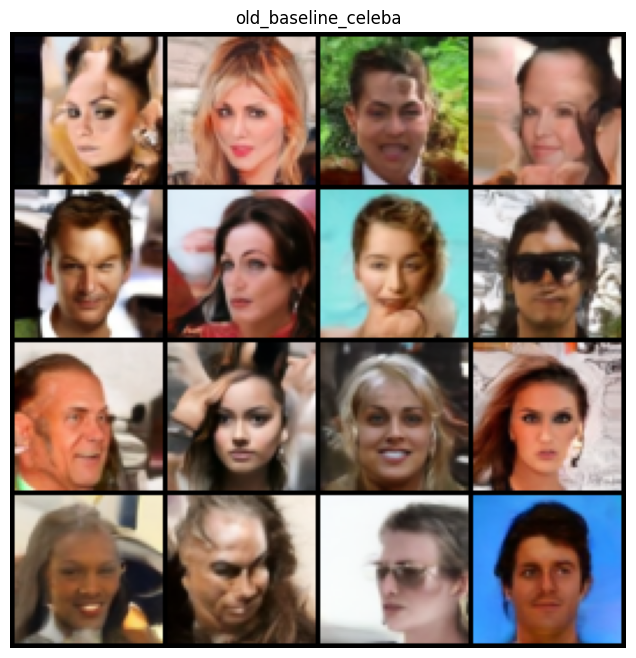

In [24]:
# for _, row in df_results.iterrows():
#     img_path = Path(row["sample_path"])
#     print(f"\n{row['exp_name']} | FID: {row['fid']} | Params(M): {row['params_million']}")

#     if img_path.exists():
#         img = Image.open(img_path)
#         plt.figure(figsize=(8, 8))
#         plt.imshow(img)
#         plt.axis("off")
#         plt.title(row["exp_name"])
#         plt.show()
#     else:
#         print("Missing:", img_path)

for _, row in df_results.iterrows():
    img_path = Path(row["sample_path"])
    print(f"\n{row['exp_name']} | FID: {row['fid']} | Params(M): {row['params_million']}")

    if img_path.exists():
        img = Image.open(img_path)
        plt.figure(figsize=(8, 8))
        plt.imshow(img)
        plt.axis("off")
        plt.title(row["exp_name"])
        plt.show()
    else:
        print("Missing:", img_path)

Cell 21 — Plot training loss

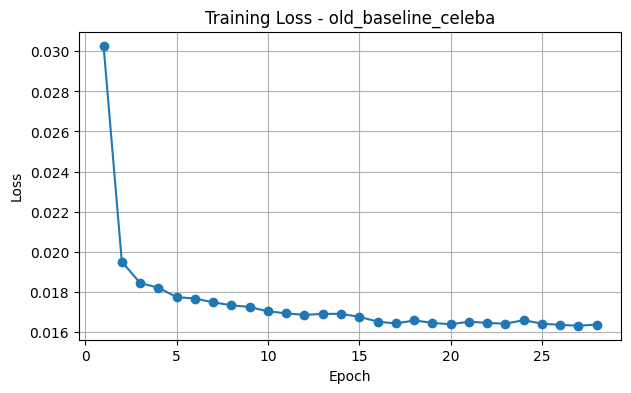

In [25]:
# def plot_log(exp_name):
#     path = trainlog_path(exp_name)
#     if not path.exists():
#         print(f"Log not found for {exp_name}")
#         return

#     data = load_json(path, default=[])
#     if len(data) == 0:
#         print(f"Empty log for {exp_name}")
#         return

#     df = pd.DataFrame(data)
#     plt.figure(figsize=(7, 4))
#     plt.plot(df["epoch"], df["loss"], marker="o")
#     plt.title(f"Training Loss - {exp_name}")
#     plt.xlabel("Epoch")
#     plt.ylabel("Loss")
#     plt.grid(True)
#     plt.show()

# for exp_name in EXPS.keys():
#     plot_log(exp_name)


def plot_log(exp_name):
    path = trainlog_path(exp_name)
    if not path.exists():
        print(f"Log not found for {exp_name}")
        return

    data = load_json(path, default=[])
    if len(data) == 0:
        print(f"Empty log for {exp_name}")
        return

    df = pd.DataFrame(data)
    plt.figure(figsize=(7, 4))
    plt.plot(df["epoch"], df["loss"], marker="o")
    plt.title(f"Training Loss - {exp_name}")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.show()

# ✅ Only plotting baseline (Variant A & B skipped)
for exp_name in EVAL_EXPS:
    plot_log(exp_name)


Cell 22 —  this week’s update tex

In [27]:
# baseline_row = df_show[df_show["exp_name"] == "old_baseline_celeba"].iloc[0]
# varA_row = df_show[df_show["exp_name"] == "variantA_celeba"].iloc[0]
# varB_row = df_show[df_show["exp_name"] == "variantB_celeba"].iloc[0]

# summary_text = f"""
# This week, we shifted our lightweight diffusion experiments from CIFAR-10 to CelebA (64×64) to obtain a more visually meaningful and research-relevant comparison setting before the final submission phase.

# Three architectures were trained and compared under a unified pipeline: an old baseline model, Proposed Variant A, and Proposed Variant B.

# The old baseline model used a heavier U-Net style configuration, while Variant A introduced a safer lightweight design through reduced channel scaling, fewer residual blocks, bottleneck-only attention, and selective depthwise separable convolution. Variant B further pushed parameter efficiency by using a smaller base width and stronger internal lightweighting.

# The evaluation was conducted using parameter count, MACs, FID, final training loss, DDIM-based sampling speed, and generated sample grids.

# Results summary:
# - Old Baseline: {baseline_row['params_million']}M params, FID {baseline_row['fid']}, speed {baseline_row['sec_per_img']} sec/img
# - Variant A: {varA_row['params_million']}M params, FID {varA_row['fid']}, speed {varA_row['sec_per_img']} sec/img, parameter reduction {varA_row['param_reduction_%_vs_baseline']}%
# - Variant B: {varB_row['params_million']}M params, FID {varB_row['fid']}, speed {varB_row['sec_per_img']} sec/img, parameter reduction {varB_row['param_reduction_%_vs_baseline']}%

# This week’s work is important because it establishes a stronger final-project direction: instead of only targeting raw image quality, the project now focuses on an efficiency-quality trade-off. The proposed lightweight variants allow us to claim a more meaningful contribution by reducing parameters and computation while maintaining competitive visual generation quality on CelebA.

# These results will directly support the final submission by helping us identify the most balanced model for the final report, comparison tables, and conclusion.
# """

# summary_path = RESULT_DIR / "this_week_update_summary.txt"
# with open(summary_path, "w") as f:
#     f.write(summary_text)

# print(summary_text)
# print("\nSaved weekly update text to:", summary_path)


# ✅ Summary text for old_baseline_celeba only
baseline_row = df_show[df_show["exp_name"] == "old_baseline_celeba"].iloc[0]

summary_text = f"""
This week, we trained and evaluated the old baseline diffusion model on CelebA (64×64).
Variant A and Variant B could not be trained in this session due to Kaggle runtime constraints —
they will be run in a separate dedicated notebook.

Old Baseline Results:
- Parameters : {baseline_row["params_million"]}M
- MACs        : {baseline_row["macs_billion"]}B
- FID Score   : {baseline_row["fid"]}
- Speed       : {baseline_row["sec_per_img"]} sec/img
- Final Loss  : {baseline_row["final_train_loss"]}
- Used EMA    : {baseline_row["used_ema"]}

Next step: train Variant A and Variant B in a separate Kaggle notebook
and merge results into the final comparison table.
"""

summary_path = RESULT_DIR / "this_week_update_summary.txt"
with open(summary_path, "w") as f:
    f.write(summary_text)

print(summary_text)
print("\nSaved weekly update text to:", summary_path)



This week, we trained and evaluated the old baseline diffusion model on CelebA (64×64).
Variant A and Variant B could not be trained in this session due to Kaggle runtime constraints —
they will be run in a separate dedicated notebook.

Old Baseline Results:
- Parameters : 53.9877M
- MACs        : 9.8471B
- FID Score   : 32.6778
- Speed       : 0.244631 sec/img
- Final Loss  : 0.016363
- Used EMA    : False

Next step: train Variant A and Variant B in a separate Kaggle notebook
and merge results into the final comparison table.


Saved weekly update text to: /kaggle/working/CSE499B_Lightweight_Diffusion/results_phase3_celeba_compare/this_week_update_summary.txt
